In [38]:
# import kagglehub
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

ModuleNotFoundError: No module named 'shap'

In [9]:
import sys
!{sys.executable} -m pip install xgboost --break-system-packages

In [10]:

# path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")
# print("Path to dataset files:", path)


In [11]:
# print(os.listdir("/root/.cache/kagglehub/datasets/taweilo/loan-approval-classification-data/versions/1"))

In [12]:
# df = pd.read_csv("/root/.cache/kagglehub/datasets/taweilo/loan-approval-classification-data/versions/1/loan_data.csv")
df = pd.read_csv("loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [13]:
df.shape

(45000, 14)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [15]:
df.describe(include="all")

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000,45000,4.500000e+04,45000.000000,45000,45000.000000,45000,45000.000000,45000.000000,45000.000000,45000.000000,45000,45000.000000
unique,NaN,2,5,NaN,NaN,4,NaN,6,NaN,NaN,NaN,NaN,2,NaN
top,NaN,male,Bachelor,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,24841,13399,NaN,NaN,23443,NaN,9153,NaN,NaN,NaN,NaN,22858,NaN
mean,27.764178,NaN,NaN,8.031905e+04,5.410333,NaN,9583.157556,NaN,11.006606,0.139725,5.867489,632.608756,NaN,0.222222
std,6.045108,NaN,NaN,8.042250e+04,6.063532,NaN,6314.886691,NaN,2.978808,0.087212,3.879702,50.435865,NaN,0.415744
min,20.000000,NaN,NaN,8.000000e+03,0.000000,NaN,500.000000,NaN,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,24.000000,NaN,NaN,4.720400e+04,1.000000,NaN,5000.000000,NaN,8.590000,0.070000,3.000000,601.000000,NaN,0.000000
50%,26.000000,NaN,NaN,6.704800e+04,4.000000,NaN,8000.000000,NaN,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,30.000000,NaN,NaN,9.578925e+04,8.000000,NaN,12237.250000,NaN,12.990000,0.190000,8.000000,670.000000,NaN,0.000000


In [16]:
age_median = df[df['person_age'] <= 100]['person_age'].median()
emp_exp_median = df[df['person_emp_exp'] <= 60]['person_emp_exp'].median()

df.loc[df['person_age'] > 100, 'person_age'] = age_median
df.loc[df['person_emp_exp'] > 60, 'person_emp_exp'] = emp_exp_median

In [17]:
print(df.isnull().sum())
print(df.duplicated().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64
0


In [18]:
status_counts = df['loan_status'].value_counts()
print(status_counts)
print((status_counts / len(df)).round(3))

loan_status
0    35000
1    10000
Name: count, dtype: int64
loan_status
0    0.778
1    0.222
Name: count, dtype: float64


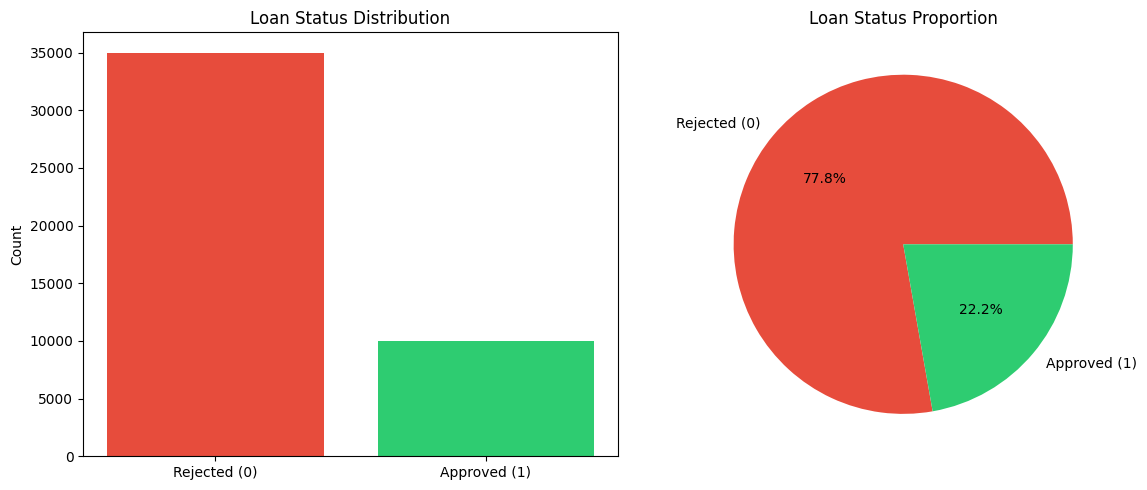

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Rejected (0)', 'Approved (1)'], 
            status_counts.values,
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Loan Status Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(status_counts.values,
            labels=['Rejected (0)', 'Approved (1)'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%')
axes[1].set_title('Loan Status Proportion')

plt.tight_layout()
plt.show()

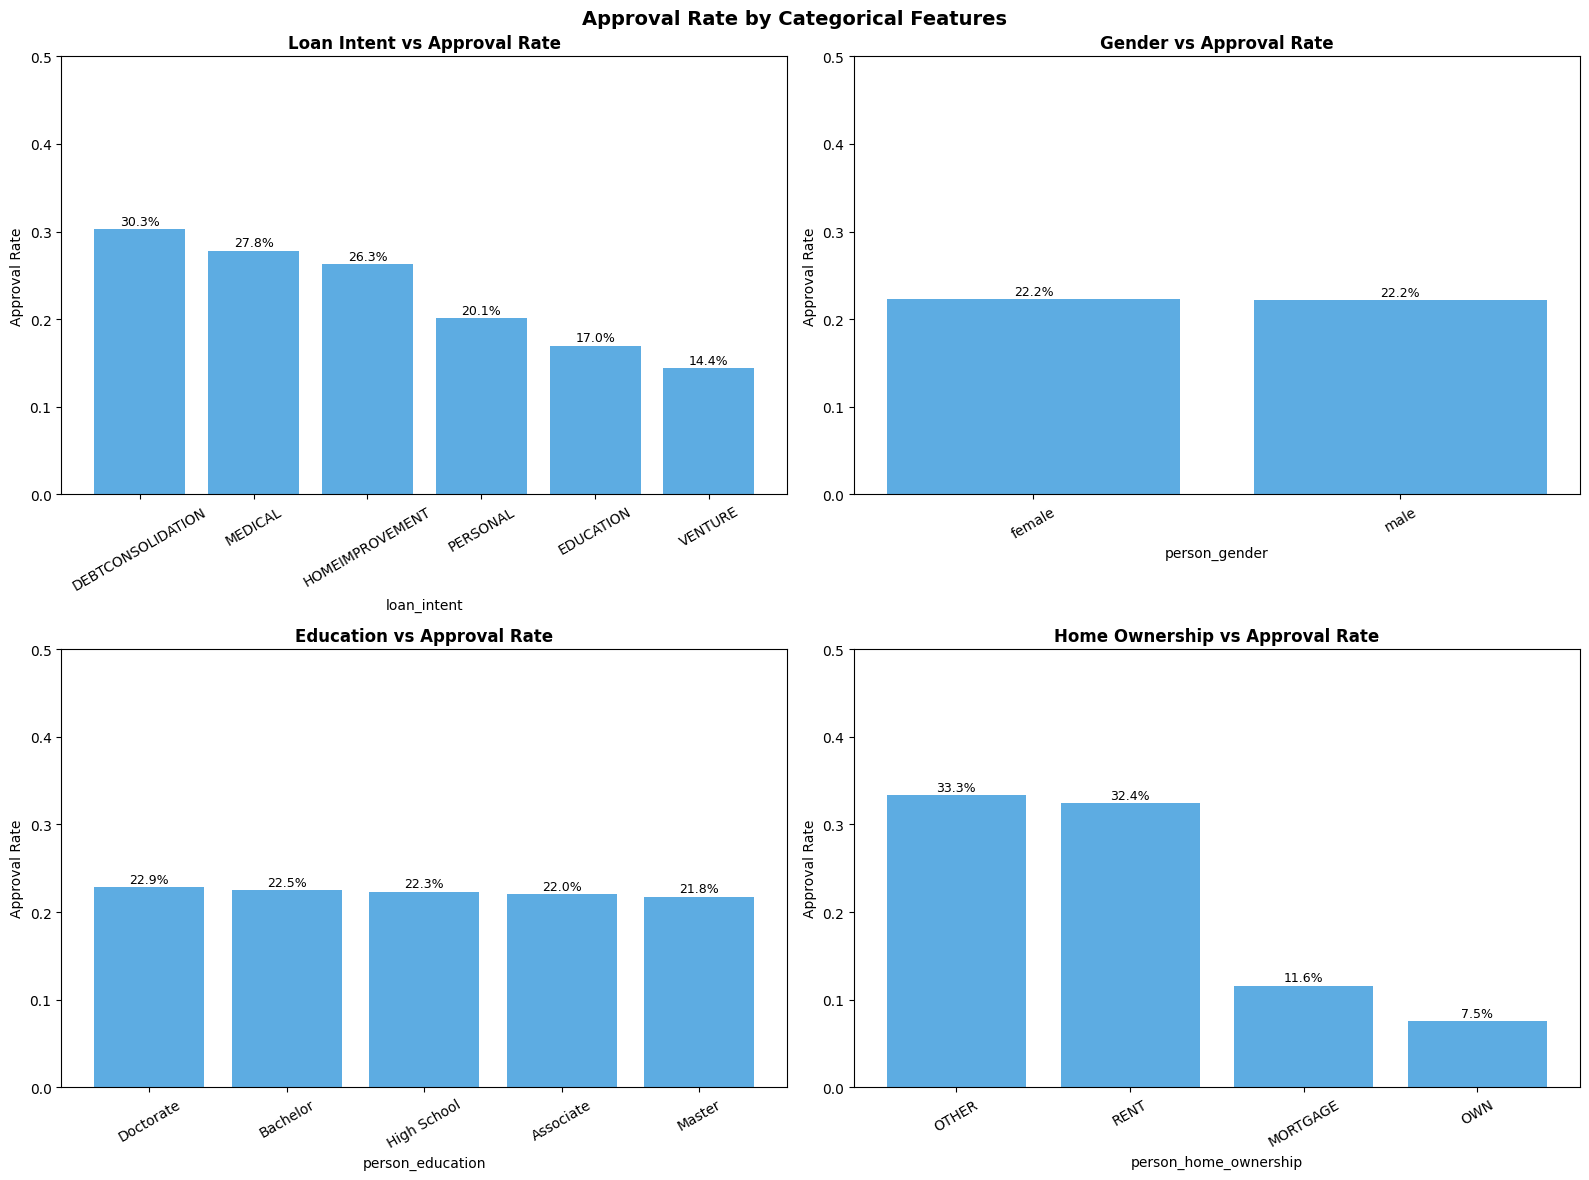

In [20]:
# Categorical Variables Analysis (Sub Q2 & Q3)
cat_cols = ['loan_intent', 'person_gender', 'person_education', 'person_home_ownership']
titles = ['Loan Intent vs Approval Rate',
          'Gender vs Approval Rate',
          'Education vs Approval Rate',
          'Home Ownership vs Approval Rate']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(cat_cols, titles)):
    approval_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    
    bars = axes[i].bar(approval_rate.index, 
                       approval_rate.values,
                       color='#3498db', alpha=0.8)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Approval Rate')
    axes[i].set_xlabel(col)
    axes[i].set_ylim(0, 0.5)
    axes[i].tick_params(axis='x', rotation=30)
    
   
    for bar, val in zip(bars, approval_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{val:.1%}', ha='center', fontsize=9)

plt.suptitle('Approval Rate by Categorical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=150)
plt.show()

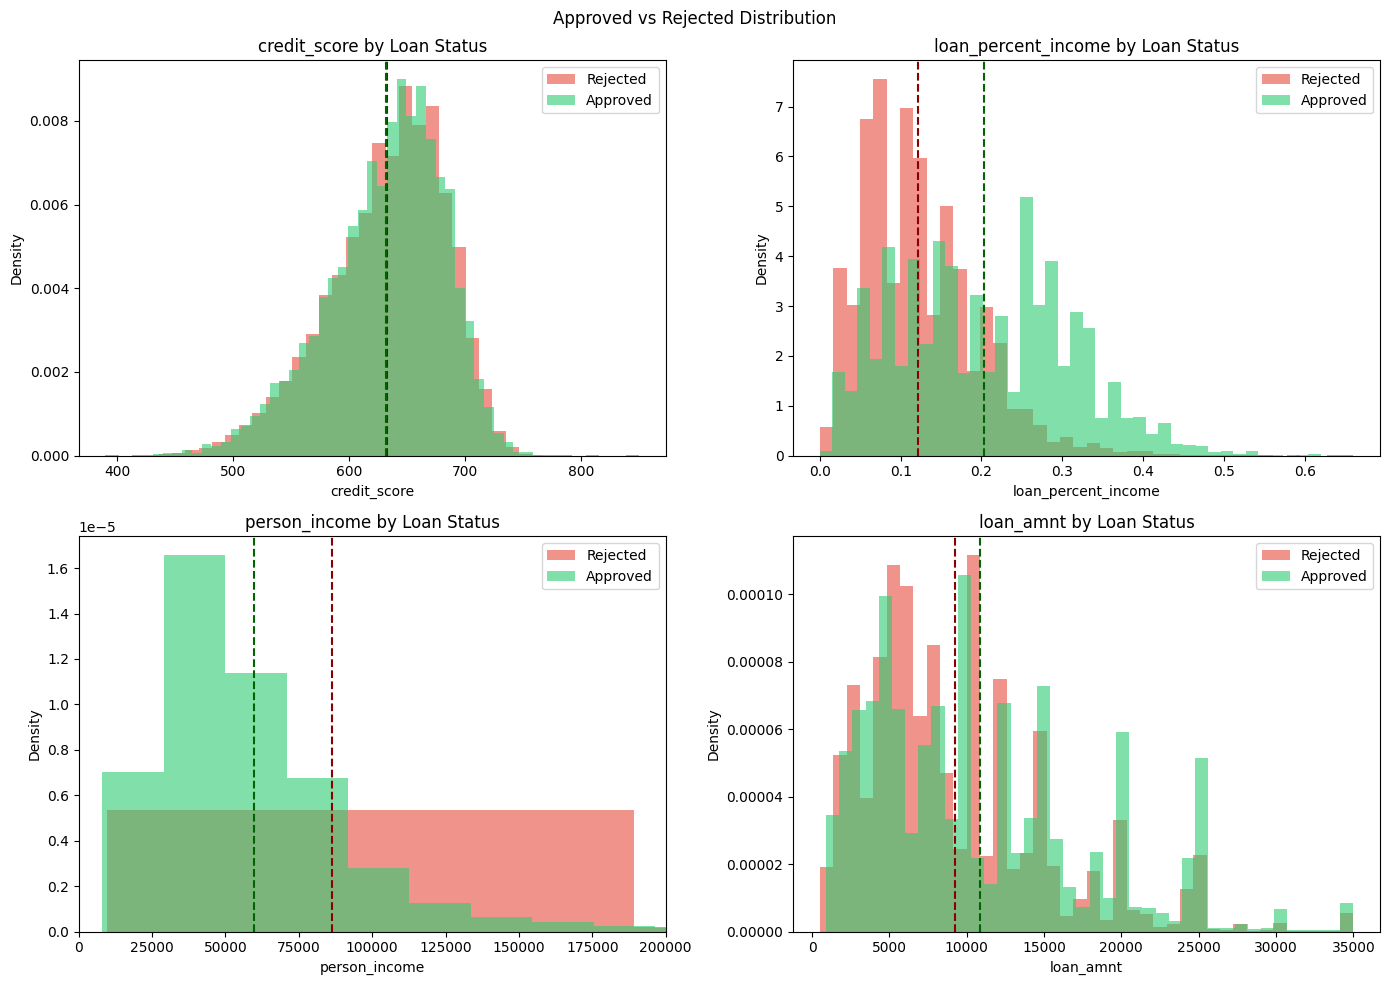

In [21]:
approved = df[df['loan_status'] == 1]
rejected = df[df['loan_status'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cols = ['credit_score', 'loan_percent_income', 'person_income', 'loan_amnt']

for i, col in enumerate(cols):
    axes[i].hist(rejected[col], bins=40, alpha=0.6, color='#e74c3c', label='Rejected', density=True)
    axes[i].hist(approved[col], bins=40, alpha=0.6, color='#2ecc71', label='Approved', density=True)
    axes[i].set_title(f'{col} by Loan Status')
    axes[i].set_ylabel('Density')
    axes[i].set_xlabel(col)
    if col == 'person_income':
        axes[i].set_xlim(0, 200000)
    axes[i].axvline(rejected[col].mean(), color='darkred', linestyle='--', linewidth=1.5)
    axes[i].axvline(approved[col].mean(), color='darkgreen', linestyle='--', linewidth=1.5)
    axes[i].legend()

plt.suptitle('Approved vs Rejected Distribution')
plt.tight_layout()
plt.show()

/var/folders/5y/lsxz79dn2z34n0fv1fy2rphm0000gn/T/ipykernel_95206/3920157027.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "loan_status", y = "credit_score", ax = axes[0],palette = 'Set2')
/var/folders/5y/lsxz79dn2z34n0fv1fy2rphm0000gn/T/ipykernel_95206/3920157027.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "loan_status", y = "loan_amnt", ax = axes[1],palette = 'Set2')


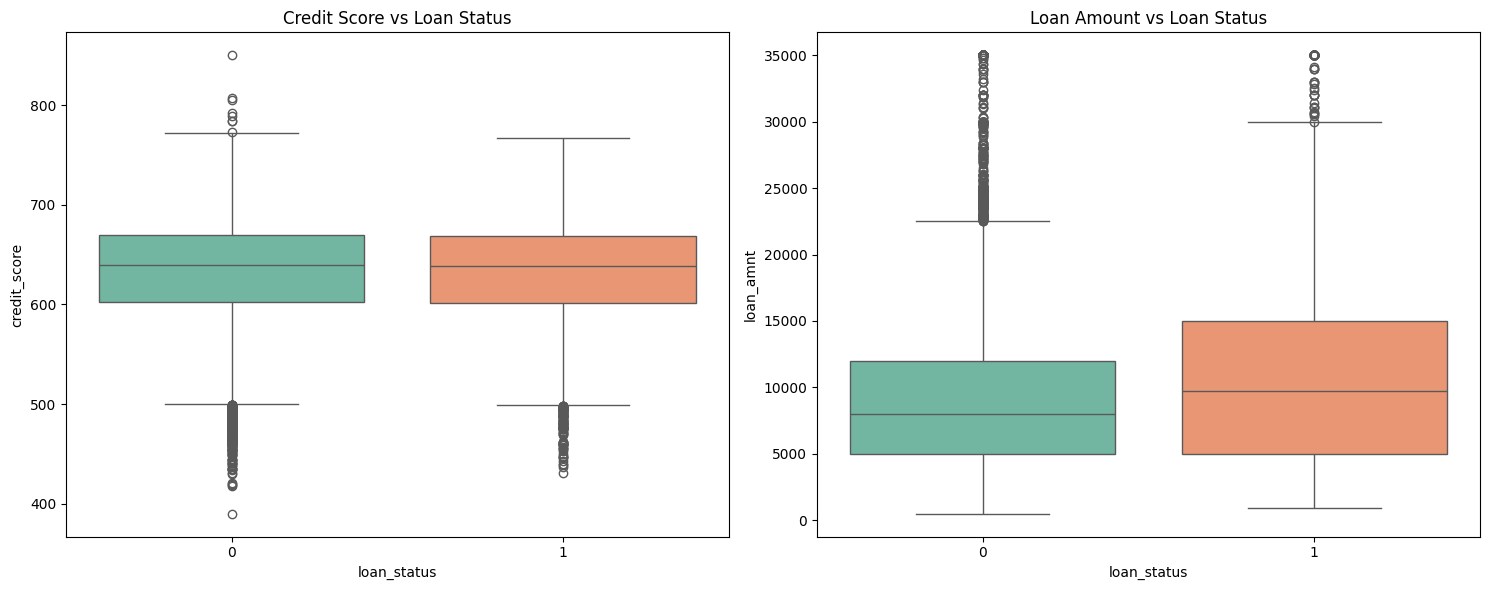

In [22]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left
sns.boxplot(data = df, x = "loan_status", y = "credit_score", ax = axes[0],palette = 'Set2')
axes[0].set_title("Credit Score vs Loan Status")

# Right
sns.boxplot(data = df, x = "loan_status", y = "loan_amnt", ax = axes[1],palette = 'Set2')
axes[1].set_title("Loan Amount vs Loan Status")
plt.tight_layout()
plt.show()

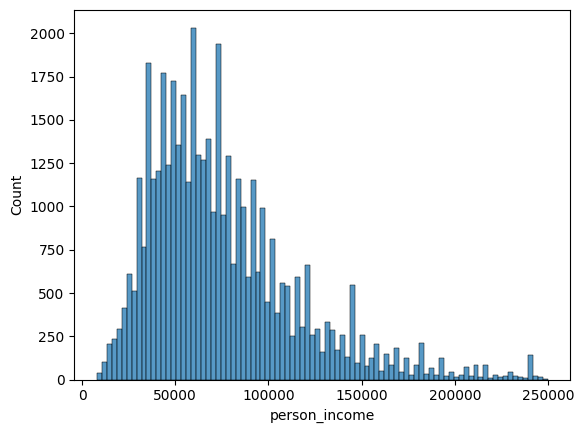

In [23]:
sns.histplot(data = df[df['person_income'] < 250000], x = 'person_income')
plt.show()

/var/folders/5y/lsxz79dn2z34n0fv1fy2rphm0000gn/T/ipykernel_95206/2998129659.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df[df['person_income'] < 200000],
/var/folders/5y/lsxz79dn2z34n0fv1fy2rphm0000gn/T/ipykernel_95206/2998129659.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'loan_status', y = 'loan_percent_income',


Text(0.5, 1.0, 'Previous Defaults vs Loan Status')

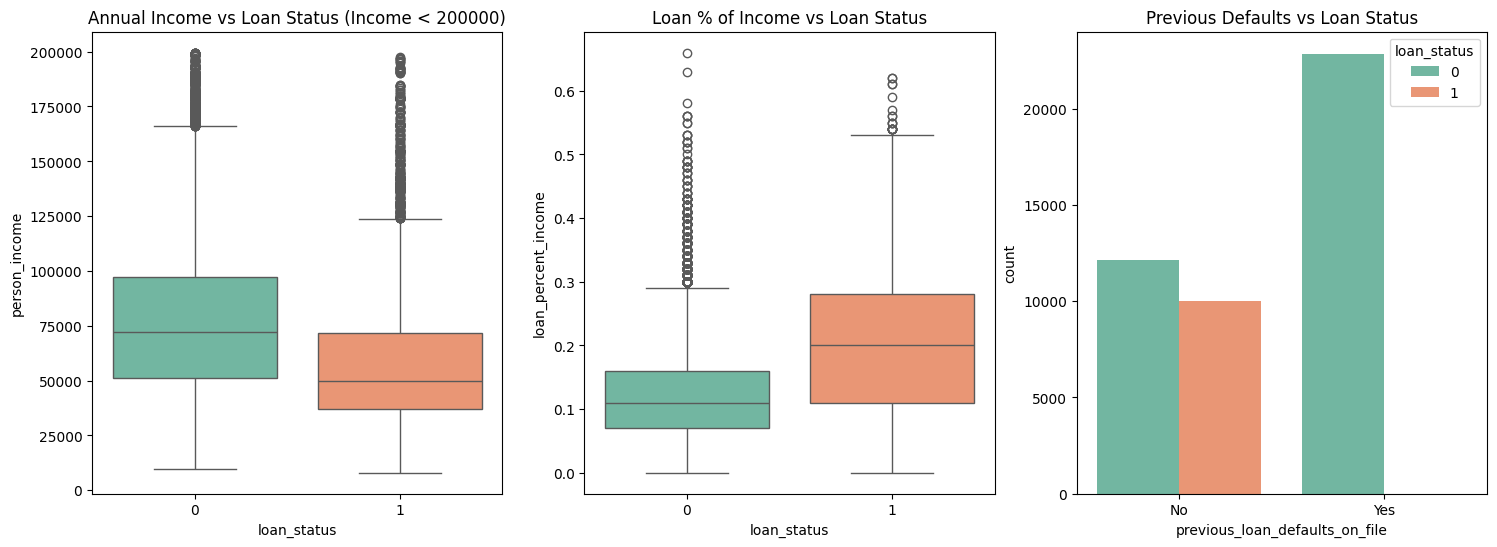

In [24]:
fig, axes = plt.subplots(1, 3, figsize = (18, 6))

# 1. Income
sns.boxplot(data = df[df['person_income'] < 200000], 
x = 'loan_status', 
y = 'person_income',
ax = axes[0], 
palette = 'Set2')
axes[0].set_title('Annual Income vs Loan Status (Income < 200000)')

# 2. Loan Percent Income
sns.boxplot(data = df, x = 'loan_status', y = 'loan_percent_income',
ax = axes[1], palette = 'Set2')
axes[1].set_title('Loan % of Income vs Loan Status')

# 3. Previous Defaults (Category)
sns.countplot(data = df, x = 'previous_loan_defaults_on_file', hue = 'loan_status',
ax = axes[2], palette = 'Set2')
axes[2].set_title("Previous Defaults vs Loan Status")

In [25]:
# Feature Engineering

# 1. Income to Employment Experience
df['income_to_emp_exp'] = df['person_income'] / (df['person_emp_exp'] + 1)

# 2. Age-Employment Ratio
df['age_emp_ratio'] = df['person_emp_exp'] / df['person_age']

# 3. Income per Age
df['income_per_age'] = df['person_income'] / df['person_age']

# 4. Credit Load
df['credit_load'] = df['loan_amnt'] / df['credit_score']

# 5. Score-to-Income Ratio
df['score_income_ratio'] = df['credit_score'] / df['person_income']

# 6. Interest Burden
df['interest_burden'] = df['loan_amnt'] * df['loan_int_rate']

# 7. Post-18 Work Ratio
df['exp_per_age'] = df['person_emp_exp'] / (df['person_age'] - 18).replace(0, 1)

# 8. Credit History to Age Ratio
df['credit_hist_to_age'] = df['cb_person_cred_hist_length'] / df['person_age']

# 9. Low-Score High-Loan Flag
df['low_score_high_loan'] = ((df['credit_score'] < 600) & 
                              (df['loan_amnt'] > 10000)).astype(int)

# 11. Monthly Payment Estimate
df['monthly_payment_estimate'] = df['loan_amnt'] * df['loan_int_rate'] / 100 / 12

# 12. Credit Score Category (0=Poor, 1=Fair, 2=Good, 3=Excellent)
df['credit_score_category'] = pd.cut(
    df['credit_score'],
    bins=[0, 580, 670, 740, 900],
    labels=[0, 1, 2, 3]
).astype(int)

# 13. Age Group
df['age_group'] = pd.cut(
    df['person_age'],
    bins=[0, 23, 27, 120],
    labels=[0, 1, 2]
).astype(int)

DT/RF - prev_default_missing counts: {0: 26974, 1: 18026}
XGBoost - previous_loan_defaults_on_file NaN: 18026


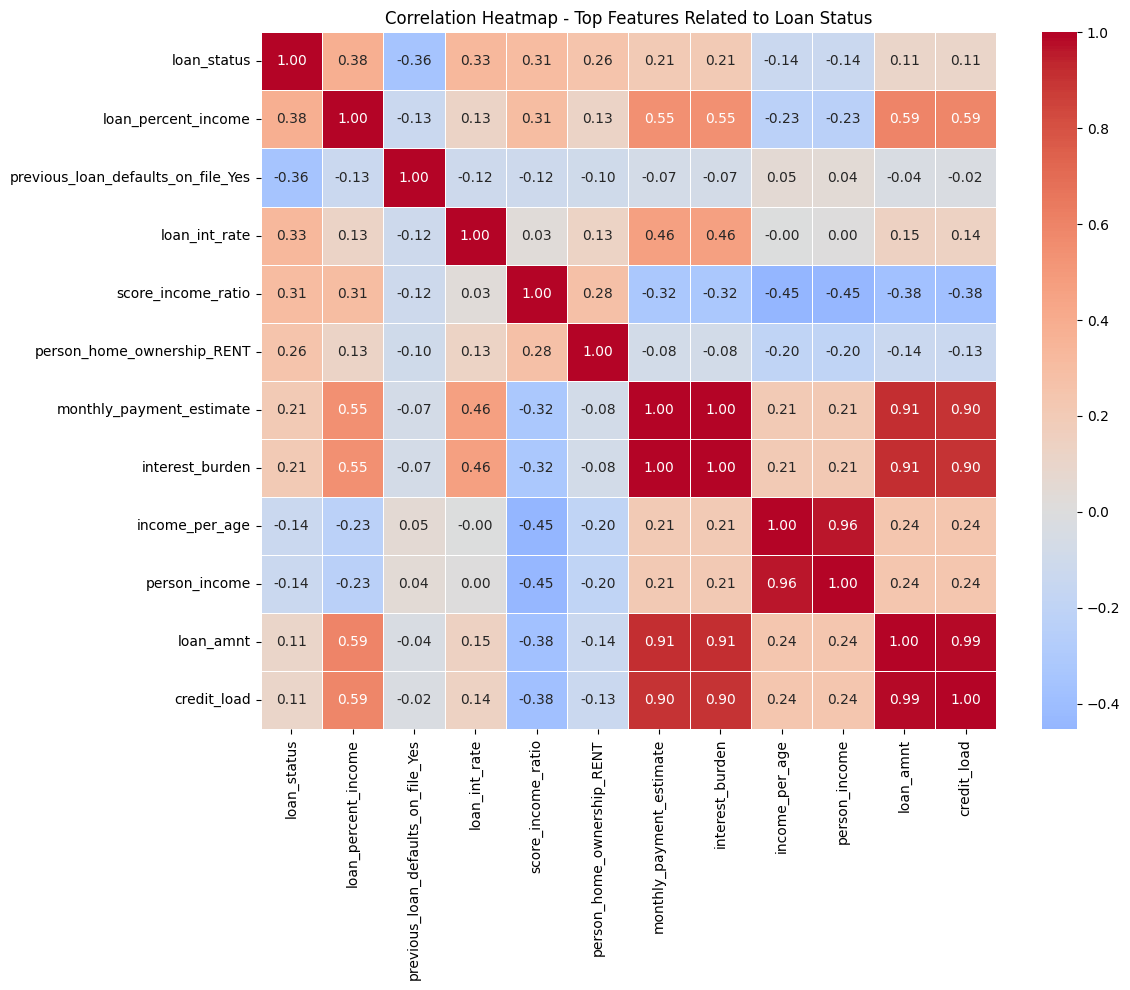

In [26]:
# Encoding

# Step 1: Ordinal Encoding
edu_order = {'High School': 0, 'Associate': 1, 'Bachelor': 2, 'Master': 3, 'Doctorate': 4}
df['person_education'] = df['person_education'].map(edu_order)

# Step 2: Binary Encoding
df['person_gender'] = df['person_gender'].map({'male': 1, 'female': 0})

# Step 3: Introduce random missing values BEFORE OHE (40% random, both Yes and No)
np.random.seed(42)
missing_mask = np.random.rand(len(df)) < 0.40
df.loc[missing_mask, 'previous_loan_defaults_on_file'] = np.nan

# Save copy for XGBoost before fillna (NaN preserved)
df_xgb_raw = df.copy()

# For DT/RF: add missing indicator + fillna with mode
df['prev_default_missing'] = df['previous_loan_defaults_on_file'].isna().astype(int)
most_freq = df['previous_loan_defaults_on_file'].mode()[0]
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].fillna(most_freq)

# Step 4: OHE for DT/RF
df_final = pd.get_dummies(df, drop_first=True, dtype=int)
df_missing = df_final.copy()
df_missing['high_risk_flag'] = ((df_missing['loan_percent_income'] > 0.3) &
                                 (df_missing['credit_score'] < 600)).astype(int)

# Step 5: Prepare XGBoost df (previous_loan_defaults_on_file stays numeric with NaN)
df_xgb_raw['previous_loan_defaults_on_file'] = df_xgb_raw['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0})
df_xgb_final = pd.get_dummies(df_xgb_raw, drop_first=True, dtype=int)
df_xgb_final['high_risk_flag'] = ((df_xgb_final['loan_percent_income'] > 0.3) &
                                   (df_xgb_final['credit_score'] < 600)).astype(int)

print("DT/RF - prev_default_missing counts:", df_missing['prev_default_missing'].value_counts().to_dict())
print("XGBoost - previous_loan_defaults_on_file NaN:", df_xgb_final['previous_loan_defaults_on_file'].isnull().sum())

# Correlation Heatmap
corr_matrix = df_final.corr()
top_features = corr_matrix['loan_status'].abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix.loc[top_features, top_features],
    annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5
)
plt.title('Correlation Heatmap - Top Features Related to Loan Status')
plt.tight_layout()
plt.show()

In [27]:
# Training/Testing Split

# DT and RF
X = df_missing.drop('loan_status', axis=1)
y = df_missing['loan_status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# XGBoost
X_xgb = df_xgb_final.drop('loan_status', axis=1)
y_xgb = df_xgb_final['loan_status']
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb
)

print(f"Train set samples: {len(X_train)}")
print(f"Test set samples: {len(X_test)}")
print(f"XGBoost Train set samples: {len(X_train_xgb)}")
print(f"XGBoost Test set samples: {len(X_test_xgb)}")

Train set samples: 36000
Test set samples: 9000
XGBoost Train set samples: 36000
XGBoost Test set samples: 9000


In [28]:
# Normalize data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler_xgb = StandardScaler()

num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
            'credit_score', 'income_to_emp_exp', 'age_emp_ratio', 'income_per_age',
            'credit_load', 'score_income_ratio', 'interest_burden', 'exp_per_age',
            'credit_hist_to_age', 'monthly_payment_estimate',
            'credit_score_category', 'age_group']

# DT/RF
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# XGBoost (filter to columns that exist in XGBoost df)
xgb_num_cols = [c for c in num_cols if c in X_train_xgb.columns]
X_train_scaled_xgb = X_train_xgb.copy()
X_test_scaled_xgb = X_test_xgb.copy()
X_train_scaled_xgb[xgb_num_cols] = scaler_xgb.fit_transform(X_train_xgb[xgb_num_cols])
X_test_scaled_xgb[xgb_num_cols] = scaler_xgb.transform(X_test_xgb[xgb_num_cols])

In [29]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, scale_pos_weight=3.5)
}
results = {}

for name, clf in models.items():
    if name == 'XGBoost':
        x_tr, x_te, y_tr, y_te = X_train_scaled_xgb, X_test_scaled_xgb, y_train_xgb, y_test_xgb
    else:
        x_tr, x_te, y_tr, y_te = X_train_scaled, X_test_scaled, y_train, y_test

    clf.fit(x_tr, y_tr)
    probs = clf.predict_proba(x_te)[:, 1]

    roc_auc = roc_auc_score(y_te, probs)
    pr_roc = average_precision_score(y_te, probs)

    results[name] = {"ROC AUC": roc_auc, "PR AUC": pr_roc, "probs": probs, "y_eval": y_te}
    print(f"{name} Complete Training")

print("\nModel Performance Ranking")
for name, metrics in results.items():
    print(f"{name}: ROC AUC = {metrics['ROC AUC']:.4f}, PR AUC = {metrics['PR AUC']:.4f}")

Decision Tree Complete Training
Random Forest Complete Training
XGBoost Complete Training

Model Performance Ranking
Decision Tree: ROC AUC = 0.9264, PR AUC = 0.8502
Random Forest: ROC AUC = 0.9501, PR AUC = 0.8919
XGBoost: ROC AUC = 0.9602, PR AUC = 0.9067


In [30]:
from sklearn import model_selection
from sklearn.metrics import average_precision_score
from sklearn.model_selection import RandomizedSearchCV

tuned_models = {}

param_grids = {
    "Decision Tree": {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_leaf': [1, 2, 4]
    },
    "XGBoost": {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0],
        'reg_alpha': [0, 1, 5],
        'reg_lambda': [1, 5, 10]
    }
}

for name, base_model in models.items():
    if name == 'XGBoost':
        x_tr, x_te, y_tr, y_te = X_train_scaled_xgb, X_test_scaled_xgb, y_train_xgb, y_test_xgb
    else:
        x_tr, x_te, y_tr, y_te = X_train_scaled, X_test_scaled, y_train, y_test

    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_grids[name],
        n_iter=20, scoring='average_precision',
        cv=3, random_state=42, n_jobs=-1
    )

    random_search.fit(x_tr, y_tr)
    best_model = random_search.best_estimator_
    tuned_probs = best_model.predict_proba(x_te)[:, 1]

    tuned_roc_auc = roc_auc_score(y_te, tuned_probs)
    tuned_pr_auc = average_precision_score(y_te, tuned_probs)

    tuned_name = f"{name} (Tuned)"
    results[tuned_name] = {
        "ROC AUC": tuned_roc_auc, "PR AUC": tuned_pr_auc,
        "probs": tuned_probs, "y_eval": y_te
    }
    tuned_models[tuned_name] = best_model
    print(f"The best parameter: {random_search.best_params_}")

The best parameter: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 7}
The best parameter: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_depth': 15}
The best parameter: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 5, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}


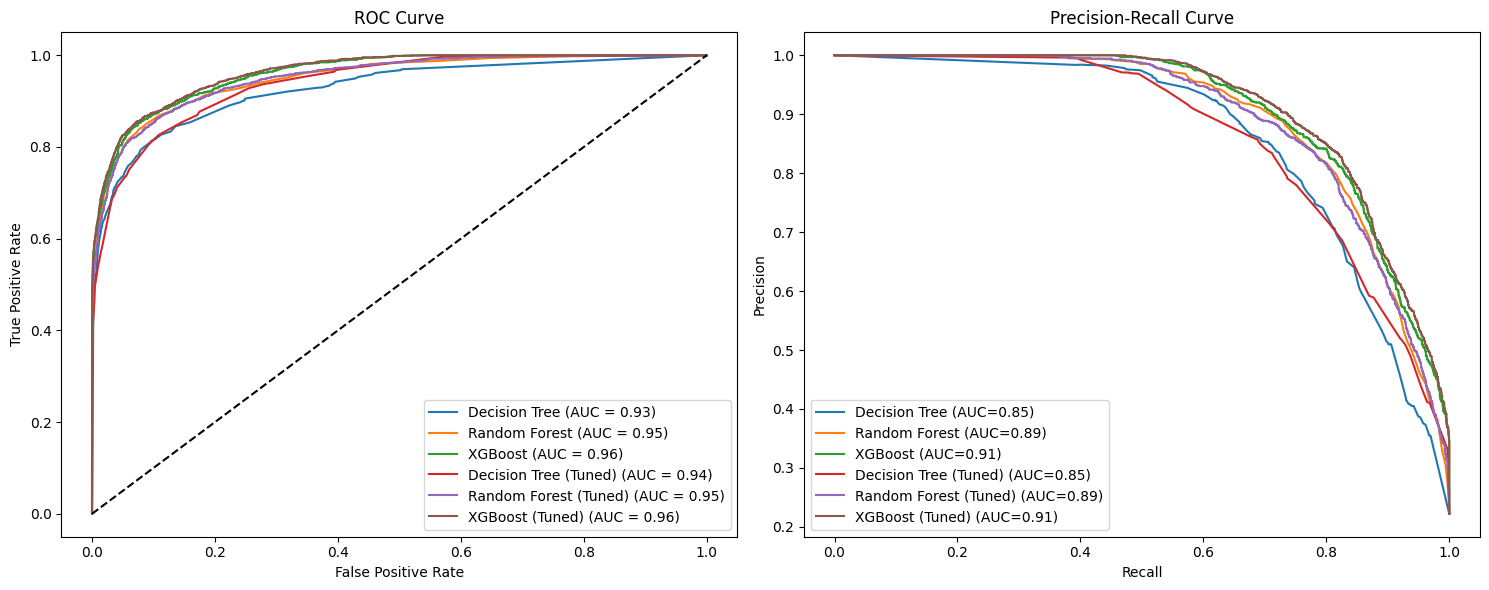

In [31]:
from sklearn.metrics import roc_curve, precision_recall_curve
plt.figure(figsize=(15, 6))

# ROC Curve
plt.subplot(1, 2, 1)
for name, m in results.items():
    fpr, tpr, _ = roc_curve(m['y_eval'], m['probs'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {m['ROC AUC']:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# PR Curve
plt.subplot(1, 2, 2)
for name, m in results.items():
    prec, rec, _ = precision_recall_curve(m['y_eval'], m['probs'])
    plt.plot(rec, prec, label=f"{name} (AUC={m['PR AUC']:.2f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()

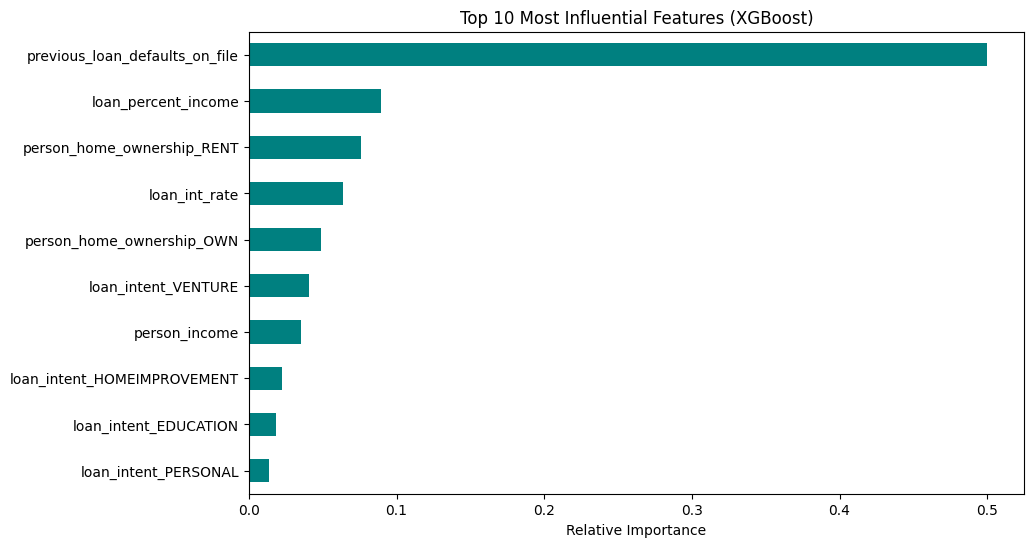

In [32]:
best_xgb_model = tuned_models["XGBoost (Tuned)"]
feat_importances = pd.Series(best_xgb_model.feature_importances_, index=X_train_scaled_xgb.columns)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Top 10 Most Influential Features (XGBoost)')
plt.xlabel('Relative Importance')
plt.show()

Best Threshold: 0.67
Highest F1-Score: 0.8525


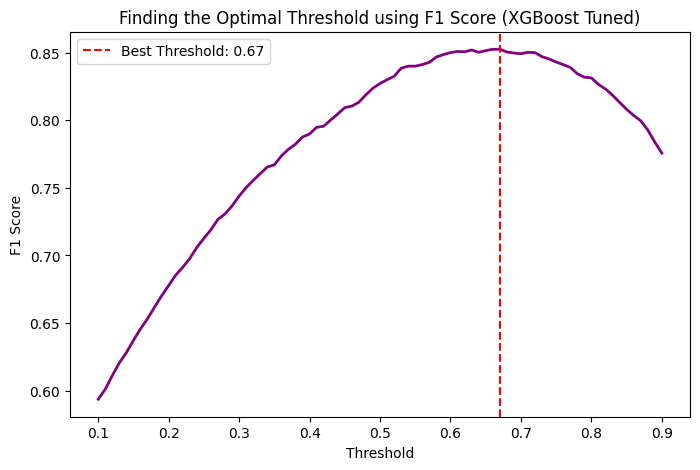

In [33]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 81)
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train_scaled_xgb, y_train_xgb,
    test_size=0.2, random_state=42
)

val_probs = tuned_models['XGBoost (Tuned)'].predict_proba(X_val)[:, 1]
f1_scores = [f1_score(y_val, (val_probs >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Highest F1-Score: {max(f1_scores):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, color='purple', lw=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Finding the Optimal Threshold using F1 Score (XGBoost Tuned)')
plt.legend()
plt.show()

In [34]:
from sklearn.metrics import precision_score, recall_score

#find out threshold  from 0.1 to 0.95 with step 0.01
thresholds = np.arange(0.1, 0.95, 0.01)
records = []

for t in thresholds:
    y_pred_t = (val_probs >= t).astype(int)
    p = precision_score(y_val, y_pred_t, zero_division=0)
    r = recall_score(y_val, y_pred_t)
    f = f1_score(y_val, y_pred_t)
    records.append((t, p, r, f))

results_df = pd.DataFrame(records, columns=['Threshold', 'Precision', 'Recall', 'F1'])

# find the highest Recall among the points where Precision >= 0.85
filtered = results_df[results_df['Precision'] >= 0.85]
best_row = filtered.loc[filtered['Recall'].idxmax()]

print(f"Best Threshold : {best_row['Threshold']:.2f}")
print(f"Precision      : {best_row['Precision']:.4f}")
print(f"Recall         : {best_row['Recall']:.4f}")
print(f"F1             : {best_row['F1']:.4f}")

Best Threshold : 0.64
Precision      : 0.8534
Recall         : 0.8471
F1             : 0.8502


Classification Report (Threshold = 0.67) 
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      7000
           1       0.84      0.81      0.82      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.88      0.89      9000
weighted avg       0.92      0.92      0.92      9000



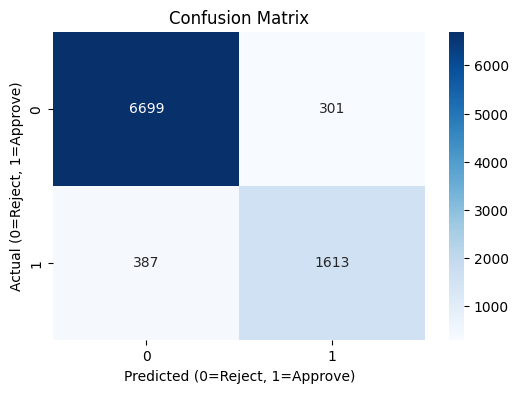

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

custom_threshold = 0.67
y_pred_custom = (results['XGBoost (Tuned)']['probs'] >= custom_threshold).astype(int)
y_eval_xgb = results['XGBoost (Tuned)']['y_eval']

print(f"Classification Report (Threshold = {custom_threshold}) ")
print(classification_report(y_eval_xgb, y_pred_custom))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_eval_xgb, y_pred_custom), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted (0=Reject, 1=Approve)')
plt.ylabel('Actual (0=Reject, 1=Approve)')
plt.title('Confusion Matrix')
plt.show()

Classification Report (Threshold = 0.63) 
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7000
           1       0.82      0.83      0.82      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.89      0.89      9000
weighted avg       0.92      0.92      0.92      9000



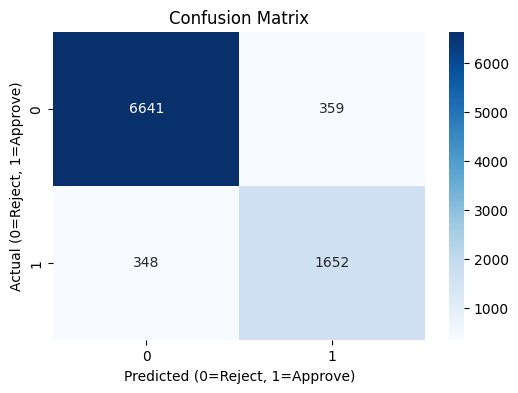

In [36]:
custom_threshold = 0.63
y_pred_custom = (results['XGBoost (Tuned)']['probs'] >= custom_threshold).astype(int)
y_eval_xgb = results['XGBoost (Tuned)']['y_eval']

print(f"Classification Report (Threshold = {custom_threshold}) ")
print(classification_report(y_eval_xgb, y_pred_custom))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_eval_xgb, y_pred_custom), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted (0=Reject, 1=Approve)')
plt.ylabel('Actual (0=Reject, 1=Approve)')
plt.title('Confusion Matrix')
plt.show()

In [37]:
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

THRESHOLD = best_threshold

print("=" * 60)
print(f"  Classification Reports for All Models (Threshold = {THRESHOLD:.2f})")
print("=" * 60)

for name, m in results.items():
    y_pred = (m['probs'] >= THRESHOLD).astype(int)
    print(f"\n--- {name} ---")
    print(classification_report(m['y_eval'], y_pred, target_names=['Rejected (0)', 'Approved (1)']))

  Classification Reports for All Models (Threshold = 0.67)

--- Decision Tree ---
              precision    recall  f1-score   support

Rejected (0)       0.93      0.94      0.94      7000
Approved (1)       0.78      0.76      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000


--- Random Forest ---
              precision    recall  f1-score   support

Rejected (0)       0.89      0.99      0.94      7000
Approved (1)       0.97      0.56      0.71      2000

    accuracy                           0.90      9000
   macro avg       0.93      0.78      0.83      9000
weighted avg       0.91      0.90      0.89      9000


--- XGBoost ---
              precision    recall  f1-score   support

Rejected (0)       0.94      0.96      0.95      7000
Approved (1)       0.84      0.80      0.82      2000

    accuracy                           0.92      9000
   mac